<a href="https://colab.research.google.com/github/Thales23006/Exercicios-Python/blob/main/Projeto_sistema_de_estoque_adjunto_a_an%C3%A1lise_de_dados(dashboard).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== SISTEMA DE ESTOQUE ===
1) Cadastrar item
2) Listar itens
3) Buscar itens (nome/categoria)
4) Movimentar estoque (Entrada/Saída)
5) Dashboard (gráficos)
0) Sair
Escolha: 1

=== Cadastro de Item ===
Nome do item: suco de laranja - 200ml
Categoria: PA
Unidade (ex: un, kg, L): un
Quantidade inicial: 1000
Valor unitário (R$): 2,00
Item cadastrado com sucesso!

=== SISTEMA DE ESTOQUE ===
1) Cadastrar item
2) Listar itens
3) Buscar itens (nome/categoria)
4) Movimentar estoque (Entrada/Saída)
5) Dashboard (gráficos)
0) Sair
Escolha: suco de uva
Opção inválida.

=== SISTEMA DE ESTOQUE ===
1) Cadastrar item
2) Listar itens
3) Buscar itens (nome/categoria)
4) Movimentar estoque (Entrada/Saída)
5) Dashboard (gráficos)
0) Sair
Escolha: 1

=== Cadastro de Item ===
Nome do item: suco de uva
Categoria: PA
Unidade (ex: un, kg, L): un
Quantidade inicial: 500
Valor unitário (R$): 2.50
Item cadastrado com sucesso!

=== SISTEMA DE ESTOQUE ===
1) Cadastrar item
2) Listar itens
3) Buscar itens (nome/cat

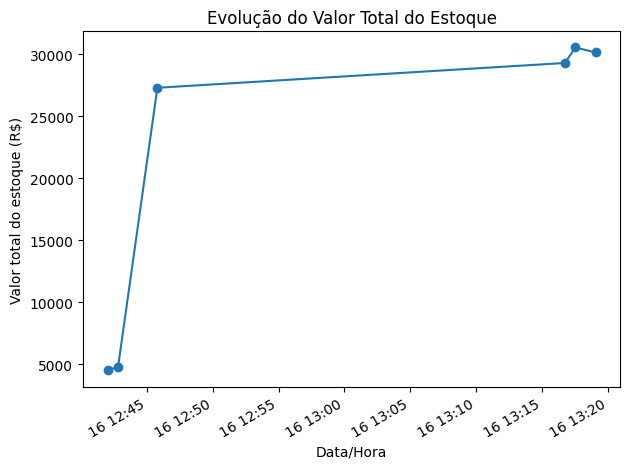

In [ ]:
import sqlite3
from datetime import datetime

DB_PATH = "estoque.db"
DATE_FMT = "%Y-%m-%d %H:%M:%S"

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

def get_conn():
    return sqlite3.connect(DB_PATH)

def create_db():
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS items (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nome TEXT NOT NULL,
        categoria TEXT NOT NULL,
        unidade TEXT NOT NULL,
        quantidade REAL NOT NULL DEFAULT 0.0,
        valor_unitario REAL NOT NULL DEFAULT 0.0
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS movimentos (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        item_id INTEGER NOT NULL,
        tipo TEXT NOT NULL,
        quantidade REAL NOT NULL,
        valor_unitario REAL NOT NULL,
        datahora TEXT NOT NULL,
        estoque_qtd_após REAL NOT NULL,
        total_estoque_após REAL NOT NULL,
        FOREIGN KEY (item_id) REFERENCES items(id)
    );
    """)
    conn.commit()
    conn.close()

def calcular_total_estoque(conn):
    cur = conn.cursor()
    cur.execute("SELECT quantidade, valor_unitario FROM items;")
    total = 0.0
    for qtd, vu in cur.fetchall():
        total += (qtd or 0.0) * (vu or 0.0)
    return total

def input_float(prompt, minimo=None):
    while True:
        val = input(prompt).replace(",", ".").strip()
        try:
            x = float(val)
            if minimo is not None and x < minimo:
                print(f"Valor deve ser >= {minimo}.")
                continue
            return x
        except ValueError:
            print("Entrada inválida. Digite um número.")

def print_item_row(row):
    _id, nome, cat, un, qtd, vu = row
    total = (qtd or 0.0) * (vu or 0.0)
    print(f"[{_id}] {nome} | Cat: {cat} | Un: {un} | Qtd: {qtd:.3f} | VU: R$ {vu:,.2f} | Total Item: R$ {total:,.2f}")

def cadastrar_item():
    print("\n=== Cadastro de Item ===")
    nome = input("Nome do item: ").strip()
    categoria = input("Categoria: ").strip()
    unidade = input("Unidade (ex: un, kg, L): ").strip()
    quantidade = input_float("Quantidade inicial: ", minimo=0.0)
    valor_unitario = input_float("Valor unitário (R$): ", minimo=0.0)
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("""
        INSERT INTO items (nome, categoria, unidade, quantidade, valor_unitario)
        VALUES (?, ?, ?, ?, ?);
    """, (nome, categoria, unidade, quantidade, valor_unitario))
    item_id = cur.lastrowid
    now = datetime.now().strftime(DATE_FMT)
    total_estoque = calcular_total_estoque(conn)
    cur.execute("""
        INSERT INTO movimentos (item_id, tipo, quantidade, valor_unitario, datahora, estoque_qtd_após, total_estoque_após)
        VALUES (?, 'init', ?, ?, ?, ?, ?);
    """, (item_id, quantidade, valor_unitario, now, quantidade, total_estoque))
    conn.commit()
    conn.close()
    print("Item cadastrado com sucesso!")

def listar_itens():
    print("\n=== Itens Cadastrados ===")
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("SELECT id, nome, categoria, unidade, quantidade, valor_unitario FROM items ORDER BY id;")
    rows = cur.fetchall()
    conn.close()
    if not rows:
        print("Nenhum item cadastrado.")
        return
    for r in rows:
        print_item_row(r)

def buscar_itens():
    print("\n=== Buscar Itens ===")
    termo = input("Buscar por (nome ou categoria, contém): ").strip()
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("""
        SELECT id, nome, categoria, unidade, quantidade, valor_unitario
        FROM items
        WHERE nome LIKE ? OR categoria LIKE ?
        ORDER BY nome;
    """, (f"%{termo}%", f"%{termo}%"))
    rows = cur.fetchall()
    conn.close()
    if not rows:
        print("Nenhum item encontrado.")
        return
    for r in rows:
        print_item_row(r)

def selecionar_item(conn):
    cur = conn.cursor()
    cur.execute("SELECT id, nome FROM items ORDER BY id;")
    rows = cur.fetchall()
    if not rows:
        print("Não há itens cadastrados.")
        return None
    print("\nSelecione o item pelo ID:")
    for _id, nome in rows:
        print(f"[{_id}] {nome}")
    while True:
        try:
            alvo = int(input("ID do item: ").strip())
            cur.execute("SELECT id FROM items WHERE id = ?;", (alvo,))
            if cur.fetchone():
                return alvo
            print("ID inválido.")
        except ValueError:
            print("Digite um número inteiro para o ID.")

def atualizar_item():
    print("\n=== Movimentar Estoque (Entrada/Saída) ===")
    conn = get_conn()
    try:
        item_id = selecionar_item(conn)
        if item_id is None:
            conn.close()
            return
        tipo = ""
        while tipo not in ("E", "S"):
            tipo = input("Tipo (E = Entrada | S = Saída): ").strip().upper()
        qtd_mov = input_float("Quantidade da movimentação: ", minimo=0.0)
        cur = conn.cursor()
        cur.execute("SELECT quantidade, valor_unitario FROM items WHERE id = ?;", (item_id,))
        row = cur.fetchone()
        if not row:
            print("Item não encontrado.")
            conn.close()
            return
        qtd_atual, vu_atual = row
        if tipo == "E":
            nova_qtd = qtd_atual + qtd_mov
            mov_tipo = "entrada"
        else:
            if qtd_mov > qtd_atual:
                print(f"Erro: saída maior que o estoque atual ({qtd_atual}). Operação cancelada.")
                conn.close()
                return
            nova_qtd = qtd_atual - qtd_mov
            mov_tipo = "saida"
        cur.execute("""
            UPDATE items
            SET quantidade = ?, valor_unitario = ?
            WHERE id = ?;
        """, (nova_qtd, vu_atual, item_id))
        total_estoque_após = calcular_total_estoque(conn)
        now = datetime.now().strftime(DATE_FMT)
        cur.execute("""
            INSERT INTO movimentos (item_id, tipo, quantidade, valor_unitario, datahora, estoque_qtd_após, total_estoque_após)
            VALUES (?, ?, ?, ?, ?, ?, ?);
        """, (item_id, mov_tipo, qtd_mov, vu_atual, now, nova_qtd, total_estoque_após))
        conn.commit()
        print("Movimentação registrada com sucesso!")
    finally:
        conn.close()

def dashboard():
    print("\n=== Dashboard ===")
    if plt is None:
        print("O módulo matplotlib não está instalado. Instale com: pip install matplotlib")
        return
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("""
        SELECT datahora, total_estoque_após
        FROM movimentos
        ORDER BY datetime(datahora);
    """)
    movs = cur.fetchall()
    if not movs:
        print("Sem movimentações para exibir.")
        conn.close()
        return
    datas_total = [datetime.strptime(d, DATE_FMT) for (d, _) in movs]
    valores_total = [v for (_, v) in movs]
    plt.figure()
    plt.plot(datas_total, valores_total, marker='o')
    plt.xlabel("Data/Hora")
    plt.ylabel("Valor total do estoque (R$)")
    plt.title("Evolução do Valor Total do Estoque")
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()
    ver_item = input("Exibir evolução de QUANTIDADE para um item específico? (s/n): ").strip().lower()
    if ver_item == "s":
        item_id = selecionar_item(conn)
        if item_id is None:
            conn.close()
            return
        cur.execute("""
            SELECT i.nome
            FROM items i
            WHERE i.id = ?;
        """, (item_id,))
        nome_item = cur.fetchone()
        nome_item = nome_item[0] if nome_item else f"Item {item_id}"
        cur.execute("""
            SELECT datahora, estoque_qtd_após
            FROM movimentos
            WHERE item_id = ?
            ORDER BY datetime(datahora);
        """, (item_id,))
        serie = cur.fetchall()
        if not serie:
            print("Este item não possui movimentações registradas.")
        else:
            datas_item = [datetime.strptime(d, DATE_FMT) for (d, _) in serie]
            qtds_item = [q for (_, q) in serie]
            plt.figure()
            plt.plot(datas_item, qtds_item, marker='o')
            plt.xlabel("Data/Hora")
            plt.ylabel(f"Quantidade ({nome_item})")
            plt.title(f"Evolução da Quantidade em Estoque — {nome_item}")
            plt.gcf().autofmt_xdate()
            plt.tight_layout()
            plt.show()
    conn.close()

def menu():
    while True:
        print("\n=== SISTEMA DE ESTOQUE ===")
        print("1) Cadastrar item")
        print("2) Listar itens")
        print("3) Buscar itens (nome/categoria)")
        print("4) Movimentar estoque (Entrada/Saída)")
        print("5) Dashboard (gráficos)")
        print("0) Sair")
        op = input("Escolha: ").strip()
        if op == "1":
            cadastrar_item()
        elif op == "2":
            listar_itens()
        elif op == "3":
            buscar_itens()
        elif op == "4":
            atualizar_item()
        elif op == "5":
            dashboard()
        elif op == "0":
            print("Até mais!")
            break
        else:
            print("Opção inválida.")

if __name__ == "__main__":
    create_db()
    menu()
